## Setup

In [1]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision import models
import torchvision.transforms.functional as TF
import torchvision

import numpy as np
import matplotlib.pyplot as plt

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda


## Carregar Modelo

In [3]:
def get_pretrained_model_optimized():
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    model.fc = nn.Linear(model.fc.in_features, 10)
    return model.to(device)

In [4]:
classes = ["airplane", "bird", "car", "cat", "deer", "dog", "horse", "monkey", "ship", "truck"]

stats_stl10 = ((0.4467, 0.4398, 0.4066), (0.2603, 0.2566, 0.2713))
BATCH_SIZE = 64

transform_pt_train = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(*stats_stl10),
])
transform_pt_test = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(*stats_stl10),
])

testset_pt = torchvision.datasets.STL10(root='./data', split='test', download=True, transform=transform_pt_test)
loader_pt_test = torch.utils.data.DataLoader(testset_pt, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

In [5]:
model_loaded = get_pretrained_model_optimized()
model_loaded.load_state_dict(torch.load('./models/model_resnet_stl10.pth', map_location=device))
model_loaded.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## Funções Auxiliares

In [6]:
def fgsm_attack(image, epsilon, data_grad):
    """
    Gera a perturbação adversarial.
    """
    # 1. Pega o sinal do gradiente (direção do maior erro)
    sign_data_grad = data_grad.sign()
    
    # 2. Cria a imagem perturbada: x + epsilon * sign(grad)
    perturbed_image = image + epsilon * sign_data_grad
    
    return perturbed_image

In [7]:
def test_adversarial_accuracy(model, loader, device, epsilons):
    """
    Roda o ataque FGSM para vários valores de epsilon e retorna as acurácias.
    """
    model.eval()
    accuracies = []
    examples = [] # Para visualização posterior

    print(f"--- Iniciando Ataque FGSM ---")
    
    for eps in epsilons:
        correct = 0
        total = 0
        adv_examples_bucket = [] # Exemplos deste epsilon específico
        
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            # Importante: Precisamos rastrear o gradiente da IMAGEM de entrada
            inputs.requires_grad = True
            
            # Forward pass
            outputs = model(inputs)
            init_pred = outputs.max(1, keepdim=True)[1]
            
            # Se o modelo já errou a original, não conta para o ataque (opcional, mas comum)
            # Aqui vamos contar tudo para ver a queda bruta de performance
            
            loss = nn.CrossEntropyLoss()(outputs, labels)
            model.zero_grad()
            loss.backward()
            
            # Coleta o gradiente da imagem
            data_grad = inputs.grad.data
            
            # Chama o ataque
            perturbed_data = fgsm_attack(inputs, eps, data_grad)
            
            # Re-classifica a imagem atacada
            output_adv = model(perturbed_data)
            final_pred = output_adv.max(1, keepdim=True)[1]
            
            # Calcula acurácia
            # Comparação batch a batch
            matches = final_pred.eq(labels.view_as(final_pred))
            correct += matches.sum().item()
            total += inputs.size(0)
            
            # Salva o primeiro exemplo de sucesso do ataque neste batch para plotar
            if len(adv_examples_bucket) < 1:
                # Pega o primeiro índice que o ataque funcionou (era correto, virou errado)
                # Ou apenas pega o primeiro do batch para simplificar
                adv_ex = perturbed_data[0].detach().cpu()
                orig_ex = inputs[0].detach().cpu()
                orig_pred = init_pred[0].item()
                adv_pred = final_pred[0].item()
                true_label = labels[0].item()
                
                adv_examples_bucket.append((orig_ex, adv_ex, true_label, orig_pred, adv_pred))

        acc = 100. * correct / total
        accuracies.append(acc)
        examples.append(adv_examples_bucket[0]) # Salva 1 exemplo por epsilon
        
        print(f"Epsilon: {eps:.2f} \tAcurácia: {acc:.2f}%")
        
    return accuracies, examples

In [ ]:
def visualize_attack(examples, epsilons, classes, stats):
    """
    Plota: Original -> Ruído -> Adversarial
    """
    mean, std = stats
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    
    # Seleciona alguns epsilons para mostrar (ex: 0.05 e 0.2)
    indices_to_show = [1, 3, 5] if len(epsilons) > 5 else [1]
    
    for idx in indices_to_show:
        if idx >= len(examples): break
        
        orig_tensor, adv_tensor, true_lbl, orig_pred, adv_pred = examples[idx]
        eps = epsilons[idx]
        
        # Desnormalizar
        img_orig = (orig_tensor * std + mean).clamp(0, 1).permute(1,2,0).numpy()
        img_adv  = (adv_tensor * std + mean).clamp(0, 1).permute(1,2,0).numpy()
        
        # Calcular o Ruído (A diferença pura)
        noise = (adv_tensor - orig_tensor).permute(1,2,0).numpy()
        # Normaliza o ruído para visualização (senão fica tudo preto/cinza)
        noise = (noise - noise.min()) / (noise.max() - noise.min() + 1e-8)
        
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        
        # 1. Original
        axes[0].imshow(img_orig)
        axes[0].set_title(f"Original\nReal: {classes[true_lbl]} | Pred: {classes[orig_pred]}")
        axes[0].axis('off')
        
        # 2. Ruído
        axes[1].imshow(noise, cmap='gray')
        axes[1].set_title(f"Perturbação (Epsilon={eps})\n(Contraste Aumentado)")
        axes[1].axis('off')
        
        # 3. Adversarial
        axes[2].imshow(img_adv)
        axes[2].set_title(f"Adversarial\nPredição: {classes[adv_pred]}")
        axes[2].axis('off')
        
        plt.tight_layout()
        plt.show()

## Ataque FGSM (Fast Gradient Sign Method)

--- Iniciando Ataque FGSM ---
Epsilon: 0.00 	Acurácia: 95.20%
Epsilon: 0.05 	Acurácia: 7.84%
Epsilon: 0.10 	Acurácia: 7.28%
Epsilon: 0.15 	Acurácia: 8.64%
Epsilon: 0.20 	Acurácia: 10.35%
Epsilon: 0.30 	Acurácia: 14.44%


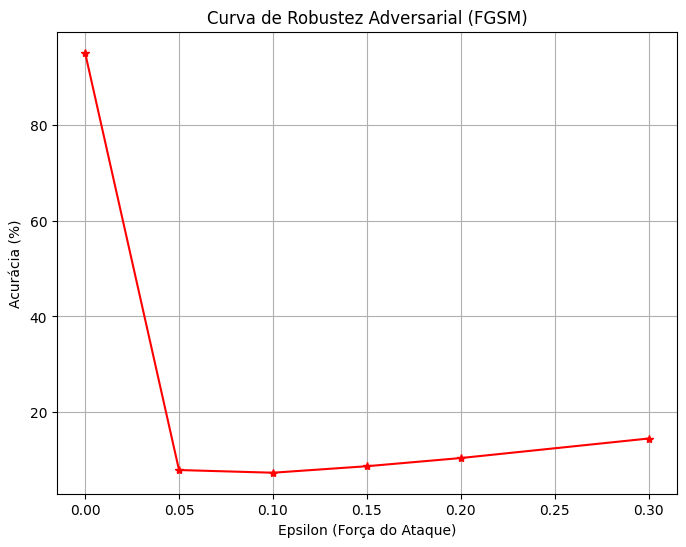

In [8]:
# Definindo as forças do ataque
# 0.0 = Baseline
# 0.3 = Ataque muito forte (a imagem começa a ficar visivelmente ruidosa)
epsilons = [0, 0.05, 0.1, 0.15, 0.2, 0.3]

accuracies, adv_examples = test_adversarial_accuracy(model_loaded, loader_pt_test, device, epsilons)

# --- Plotando a Curva de Queda ---
plt.figure(figsize=(8, 6))
plt.plot(epsilons, accuracies, "*-", color='red')
plt.title("Curva de Robustez Adversarial (FGSM)")
plt.xlabel("Epsilon (Força do Ataque)")
plt.ylabel("Acurácia (%)")
plt.grid(True)
plt.show()

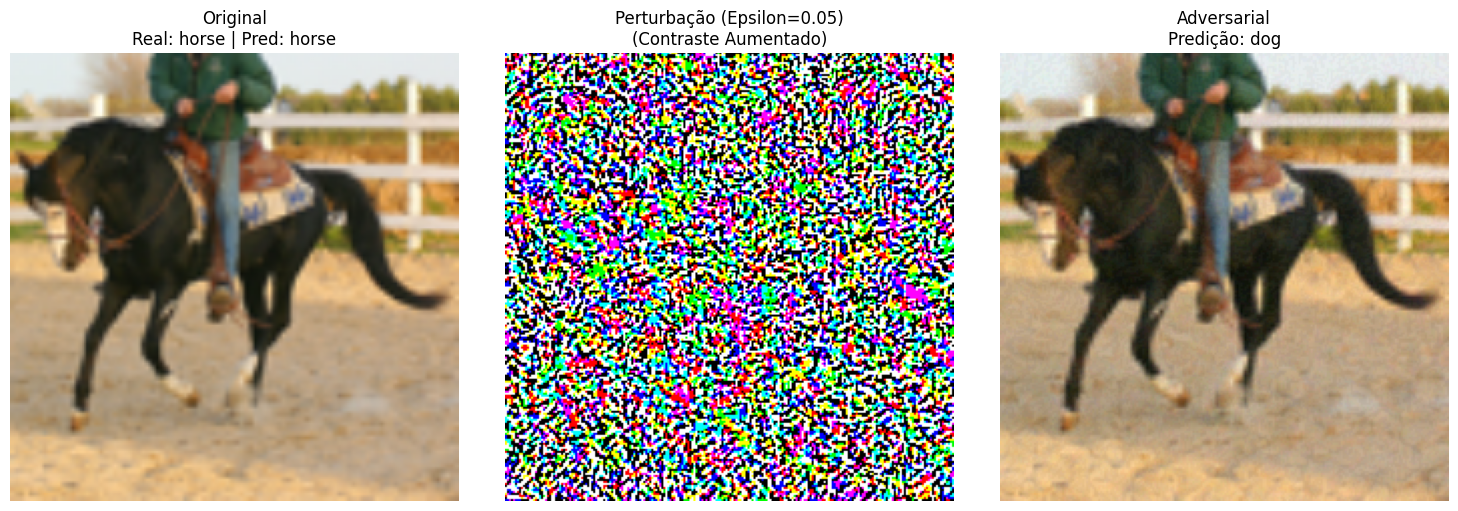

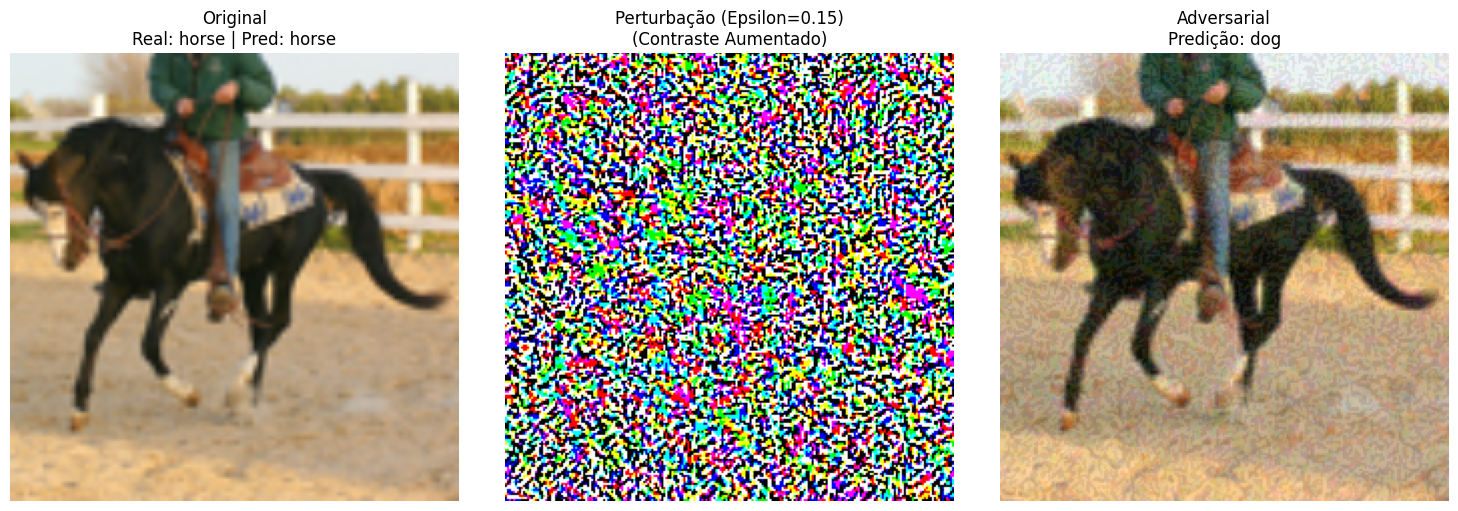

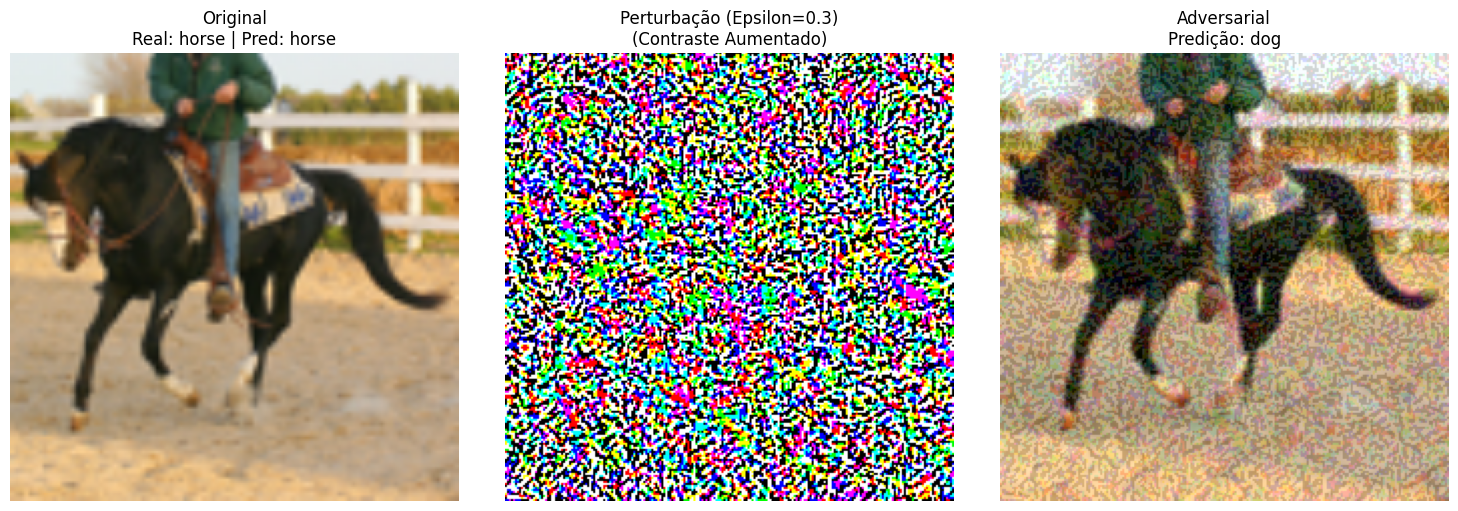

In [ ]:
# Rodar visualização
visualize_attack(adv_examples, epsilons, loader_pt_test.dataset.classes, stats_stl10)